In [26]:

# ============================================================
# 0) CONFIGURACIÓN
# ============================================================
from pathlib import Path
import json
import ast
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 220)
pd.set_option("display.max_colwidth", 140)

# Ajusta solo si quieres forzar una ruta manual.
BASE_DIR = Path(r"D:\QuantMahoraga\final_model\news_mahoraga")
RAW_CANDIDATES = [
    BASE_DIR / "news_data" / "raw" / "news_raw_gdelt.parquet",
    BASE_DIR / "news_data" / "raw" / "news_raw_gdelt_en.parquet",
    Path.cwd() / "news_raw_gdelt.parquet",
    Path.cwd() / "news_raw_gdelt_en.parquet",
]

RAW_PATH = next((p for p in RAW_CANDIDATES if p.exists()), RAW_CANDIDATES[0])

print("BASE_DIR:", BASE_DIR)
print("RAW_PATH :", RAW_PATH)
print("EXISTE   :", RAW_PATH.exists())
print("CWD      :", Path.cwd())


BASE_DIR: D:\QuantMahoraga\final_model\news_mahoraga
RAW_PATH : D:\QuantMahoraga\final_model\news_mahoraga\news_data\raw\news_raw_gdelt.parquet
EXISTE   : True
CWD      : d:\QuantMahoraga\final_model\news_mahoraga\news_data\raw


In [27]:

# ============================================================
# 1) CARGA
# ============================================================
if not RAW_PATH.exists():
    raise FileNotFoundError(
        f"No se encontró el archivo crudo. Revisa RAW_PATH o coloca el archivo en alguna de estas rutas:\n" +
        "\n".join(str(p) for p in RAW_CANDIDATES)
    )

df = pd.read_parquet(RAW_PATH)
print("Shape:", df.shape)
display(df.head(3))
display(df.sample(min(3, len(df)), random_state=42))


Shape: (50624, 15)


,news_id,timestamp,source,headline,snippet,body,language,ticker_tags,topic,url,domain,sourcecountry,gdelt_query,fetched_ok,extract_ok
0,00061b3c649f6fd7fd198243f04e3e46bbf6fb75,2025-02-25T23:30:00+00:00,businessinsider.com,Readers told us that maybe DOGE's email request is a good idea,"Readers shared their takes on DOGE's controversial request for accomplishment lists — many saw potential benefits, despite concerns abou...",- BI readers told us how they'd answer the DOGE email asking for a list of work accomplishments. - Nearly half of you said you'd be happ...,English,[],universe,https://www.businessinsider.com/doge-federal-workers-email-good-ideas-responses-poll-2025-2,businessinsider.com,United States,(AAPL OR Apple OR MSFT OR Microsoft OR NVDA OR Nvidia OR GOOGL OR Google OR AMZN OR Amazon OR META OR Meta OR AVGO OR Broadcom OR ASML O...,True,True
1,0007ffccc7ca5d9941bef860bbd727e41837f6f6,2025-01-24T23:15:00+00:00,edaily.co.kr,글로벌 생명과학 M&A 올해 트렌드는?[제약·바이오 해외토픽],올해 글로벌 생명과학(헬스케어) 인수합병(M&A) 트렌드는 인공지능(AI)과 중국이 될 것이란 전망이 제기됐다. 인공지능. (사진=연합뉴스)25일 한국바이오협회 바이오경제연구센터에 따르면 글로벌 생명과학분야에 있어 지난해는 리셋의 해로 평가된다...,[이데일리 신민준 기자] 올해 글로벌 생명과학(헬스케어) 인수합병(M&A) 트렌드는 인공지능(AI)과 중국이 될 것이란 전망이 제기됐다. | | 인공지능. (사진=연합뉴스) | | 25일 한국바이오협회 바이오경제연구센터에 따르면 글로벌 생명과학...,Korean,[],tech_ai,https://www.edaily.co.kr/News/Read?newsId=01502246642041328&mediaCodeNo=257,edaily.co.kr,South Korea,"(""artificial intelligence"" OR AI OR semiconductor OR chip OR gpu OR datacenter OR cloud OR ""export controls"" OR antitrust OR ""AI bubble"")",True,True
2,00080fba2b267a74d1a017290091473aebcc8c34,2025-01-28T00:15:00+00:00,palestinechronicle.com,"Sheikh Qassem : No Deadline Extensions , Resistance Will Decide the Response",,,English,[],tech_ai,https://www.palestinechronicle.com/sheikh-qassem-no-deadline-extensions-resistance-will-decide-the-response/,palestinechronicle.com,Israel,"(""artificial intelligence"" OR AI OR semiconductor OR chip OR gpu OR datacenter OR cloud OR ""export controls"" OR antitrust OR ""AI bubble"")",False,False


,news_id,timestamp,source,headline,snippet,body,language,ticker_tags,topic,url,domain,sourcecountry,gdelt_query,fetched_ok,extract_ok
5026,1962cf381eeaa64e9b1f5ab8d8e891cf897782cb,2025-01-11T23:30:00+00:00,97zokonline.com,More Data Showing Outflow of People from Illinois,"The Land of Lincoln sits at 6th worst, which is an improvement from recent years.",More Data Showing Outflow of People from Illinois With 2024 behind us U-Haul released their annual “Growth Index” of states people are m...,English,[],macro_risk,https://97zokonline.com/ixp/462/p/more-data-showing-outflow-of-people-from-illinois/,97zokonline.com,United States,"(""federal reserve"" OR fomc OR inflation OR unemployment OR recession OR ""credit crisis"" OR ""banking crisis"" OR tariffs OR sanctions OR w...",True,True
46776,ec8e2925d83cceeb0d7be8dde8230dd45d79f900,2025-03-02T00:15:00+00:00,theshillongtimes.com,"The Parenting trailer: Lisa Kudrow, Brian Cox face haunted house chaos in horror-comedy drama",,"The trailer for the highly anticipated horror-comedy ‘The Parenting’ has dropped, offering a glimpse of a haunted house, family mayhem, ...",English,[],universe,https://theshillongtimes.com/2025/03/02/the-parenting-trailer-lisa-kudrow-brian-cox-face-haunted-house-chaos-in-horror-comedy-drama/,theshillongtimes.com,India,(AAPL OR Apple OR MSFT OR Microsoft OR NVDA OR Nvidia OR GOOGL OR Google OR AMZN OR Amazon OR META OR Meta OR AVGO OR Broadcom OR ASML O...,True,True
16380,53138923d52fd72839c0a1b36864fbbbcf954182,2025-02-03T00:00:00+00:00,mobile.zol.com.cn,vivo S20 Pro推荐：六边形的轻薄战士,vivoS20Pro在影像表现方面堪称一大亮点，特别适合喜欢拍摄的用户。它配备了5000万像素的旗舰柔光四主摄系统，前置5000万像素的防畸变追焦自拍镜头，辅以广角双柔光灯，支持AI3D虚拟补光和AI脸型矫正，即使在暗光或逆,vivo S20 Pro在影像表现方面堪称一大亮点，特别适合喜欢拍摄的用户。它配备了5000万像素的旗舰柔光四主摄系统，前置5000万像素的防畸变追焦自拍镜头，辅以广角双柔光灯，支持AI 3D虚拟补光和AI脸型矫正，即使在暗光或逆光环境下，也能确保自拍效果清晰、自然、亮丽...,Chinese,[],tech_ai,https://mobile.zol.com.cn/941/9415325.html,mobile.zol.com.cn,China,"(""artificial intelligence"" OR AI OR semiconductor OR chip OR gpu OR datacenter OR cloud OR ""export controls"" OR antitrust OR ""AI bubble"")",True,True


In [28]:

# ============================================================
# 2) FUNCIONES ROBUSTAS
# ============================================================
def safe_isna_scalar(x):
    try:
        return bool(pd.isna(x))
    except Exception:
        return False

def norm_text(x):
    if x is None:
        return ""
    if isinstance(x, (list, tuple, dict, set, np.ndarray)):
        return str(x)
    if safe_isna_scalar(x):
        return ""
    s = str(x).strip()
    s = re.sub(r"\s+", " ", s)
    return s

def to_list_safe(x):
    if x is None:
        return []
    if isinstance(x, np.ndarray):
        x = x.tolist()
    if isinstance(x, list):
        return [str(v).strip().upper() for v in x if str(v).strip()]
    if isinstance(x, tuple):
        return [str(v).strip().upper() for v in x if str(v).strip()]
    if isinstance(x, set):
        return [str(v).strip().upper() for v in sorted(list(x)) if str(v).strip()]
    if safe_isna_scalar(x):
        return []
    s = str(x).strip()
    if not s:
        return []
    try:
        obj = json.loads(s)
        if isinstance(obj, list):
            return [str(v).strip().upper() for v in obj if str(v).strip()]
    except Exception:
        pass
    try:
        obj = ast.literal_eval(s)
        if isinstance(obj, list):
            return [str(v).strip().upper() for v in obj if str(v).strip()]
    except Exception:
        pass
    parts = re.split(r"[,\|;/]+", s.strip("[]"))
    return [p.strip().strip('"').strip("'").upper() for p in parts if p.strip()]

def safe_scalar_for_hash(x):
    if isinstance(x, np.ndarray):
        return tuple(x.tolist())
    if isinstance(x, list):
        return tuple(x)
    if isinstance(x, tuple):
        return tuple(x)
    if isinstance(x, dict):
        return json.dumps(x, sort_keys=True, ensure_ascii=False)
    if isinstance(x, set):
        return tuple(sorted(list(x)))
    return x

def safe_nunique(series):
    try:
        return series.nunique(dropna=True)
    except Exception:
        s = series.map(safe_scalar_for_hash)
        return s.nunique(dropna=True)

def value_counts_safe(series, top_n=20):
    s = series.map(lambda x: safe_scalar_for_hash(x))
    out = s.value_counts(dropna=False).head(top_n)
    return out.rename_axis("value").reset_index(name="count")

def describe_series_safe(series, quantiles=None):
    quantiles = quantiles or [0.1, 0.25, 0.5, 0.75, 0.9, 0.95]
    s = pd.to_numeric(series, errors="coerce")
    return s.describe(percentiles=quantiles)

print("Funciones robustas cargadas.")


Funciones robustas cargadas.


In [29]:

# ============================================================
# 3) VISTA GENERAL DE COLUMNAS Y TIPOS
# ============================================================
info_df = pd.DataFrame({
    "column": df.columns,
    "dtype": [str(df[c].dtype) for c in df.columns],
    "non_null": [int(df[c].notna().sum()) for c in df.columns],
    "nulls": [int(df[c].isna().sum()) for c in df.columns],
    "null_pct": [round(float(df[c].isna().mean() * 100), 2) for c in df.columns],
    "nunique": [int(safe_nunique(df[c])) for c in df.columns],
})
display(info_df.sort_values(["null_pct", "nunique"], ascending=[False, False]))


,column,dtype,non_null,nulls,null_pct,nunique
0,news_id,object,50624,0,0.0,50624
9,url,object,50624,0,0.0,50624
3,headline,object,50624,0,0.0,43514
5,body,object,50624,0,0.0,34820
4,snippet,object,50624,0,0.0,32470
2,source,object,50624,0,0.0,8012
10,domain,object,50624,0,0.0,8012
1,timestamp,object,50624,0,0.0,473
11,sourcecountry,object,50624,0,0.0,163
7,ticker_tags,object,50624,0,0.0,82


In [30]:

# ============================================================
# 4) DETECTAR COLUMNAS PROBLEMÁTICAS
# ============================================================
problem_cols = []
for c in df.columns:
    sample_types = df[c].dropna().head(20).map(lambda x: type(x).__name__).unique().tolist()
    has_nested = any(t in {"list", "dict", "ndarray", "set", "tuple"} for t in sample_types)
    problem_cols.append({
        "column": c,
        "sample_types": sample_types,
        "has_nested_objects": has_nested,
    })
problem_cols = pd.DataFrame(problem_cols)
display(problem_cols.sort_values(["has_nested_objects", "column"], ascending=[False, True]))


,column,sample_types,has_nested_objects
7,ticker_tags,[ndarray],True
5,body,[str],False
10,domain,[str],False
14,extract_ok,[bool],False
13,fetched_ok,[bool],False
12,gdelt_query,[str],False
3,headline,[str],False
6,language,[str],False
0,news_id,[str],False
4,snippet,[str],False


In [31]:

# ============================================================
# 5) NORMALIZACIÓN BÁSICA PARA EDA
# ============================================================
eda = df.copy()

# timestamps
if "timestamp" in eda.columns and "timestamp_utc" not in eda.columns:
    eda["timestamp_utc"] = pd.to_datetime(eda["timestamp"], errors="coerce", utc=True)
elif "timestamp_utc" in eda.columns:
    eda["timestamp_utc"] = pd.to_datetime(eda["timestamp_utc"], errors="coerce", utc=True)
else:
    eda["timestamp_utc"] = pd.NaT

# textos
for c in ["source", "headline", "snippet", "body", "language", "topic", "url", "domain", "sourcecountry"]:
    if c in eda.columns:
        eda[c] = eda[c].map(norm_text)
    else:
        eda[c] = ""

# ticker tags
if "ticker_tags" in eda.columns:
    eda["ticker_tags_list"] = eda["ticker_tags"].map(to_list_safe)
else:
    eda["ticker_tags_list"] = [[] for _ in range(len(eda))]

# métricas de texto
eda["headline_len"] = eda["headline"].fillna("").str.len()
eda["snippet_len"] = eda["snippet"].fillna("").str.len()
eda["body_len"] = eda["body"].fillna("").str.len()
eda["full_text"] = (
    eda["headline"].fillna("") + " " +
    eda["snippet"].fillna("") + " " +
    eda["body"].fillna("")
).str.strip()
eda["full_text_len"] = eda["full_text"].str.len()
eda["has_text"] = eda["full_text_len"] > 50

# columnas booleanas robustas
for bcol in ["extract_ok", "fetched_ok"]:
    if bcol in eda.columns:
        eda[bcol] = eda[bcol].fillna(False).astype(bool)
    else:
        eda[bcol] = False

# normalizados
eda["language_norm"] = eda["language"].str.lower().str.strip().replace("", "unknown")
eda["source_norm"] = eda["source"].str.lower().str.strip().replace("", "unknown")
eda["topic_norm"] = eda["topic"].str.lower().str.strip().replace("", "unknown")
eda["domain_norm"] = eda["domain"].str.lower().str.strip().replace("", "unknown")

# week_end
if eda["timestamp_utc"].notna().any():
    eda["week_end"] = (
        eda["timestamp_utc"]
        .dt.tz_convert("UTC")
        .dt.tz_localize(None)
        .dt.to_period("W-FRI")
        .dt.end_time
        .dt.normalize()
    )
else:
    eda["week_end"] = pd.NaT

print("EDA shape:", eda.shape)
display(eda.head(2))


EDA shape: (50624, 28)


,news_id,timestamp,source,headline,snippet,body,language,ticker_tags,topic,url,domain,sourcecountry,gdelt_query,fetched_ok,extract_ok,timestamp_utc,ticker_tags_list,headline_len,snippet_len,body_len,full_text,full_text_len,has_text,language_norm,source_norm,topic_norm,domain_norm,week_end
0,00061b3c649f6fd7fd198243f04e3e46bbf6fb75,2025-02-25T23:30:00+00:00,businessinsider.com,Readers told us that maybe DOGE's email request is a good idea,"Readers shared their takes on DOGE's controversial request for accomplishment lists — many saw potential benefits, despite concerns abou...",- BI readers told us how they'd answer the DOGE email asking for a list of work accomplishments. - Nearly half of you said you'd be happ...,English,[],universe,https://www.businessinsider.com/doge-federal-workers-email-good-ideas-responses-poll-2025-2,businessinsider.com,United States,(AAPL OR Apple OR MSFT OR Microsoft OR NVDA OR Nvidia OR GOOGL OR Google OR AMZN OR Amazon OR META OR Meta OR AVGO OR Broadcom OR ASML O...,True,True,2025-02-25 23:30:00+00:00,[],62,146,5437,Readers told us that maybe DOGE's email request is a good idea Readers shared their takes on DOGE's controversial request for accomplish...,5647,True,english,businessinsider.com,universe,businessinsider.com,2025-02-28
1,0007ffccc7ca5d9941bef860bbd727e41837f6f6,2025-01-24T23:15:00+00:00,edaily.co.kr,글로벌 생명과학 M&A 올해 트렌드는?[제약·바이오 해외토픽],올해 글로벌 생명과학(헬스케어) 인수합병(M&A) 트렌드는 인공지능(AI)과 중국이 될 것이란 전망이 제기됐다. 인공지능. (사진=연합뉴스)25일 한국바이오협회 바이오경제연구센터에 따르면 글로벌 생명과학분야에 있어 지난해는 리셋의 해로 평가된다...,[이데일리 신민준 기자] 올해 글로벌 생명과학(헬스케어) 인수합병(M&A) 트렌드는 인공지능(AI)과 중국이 될 것이란 전망이 제기됐다. | | 인공지능. (사진=연합뉴스) | | 25일 한국바이오협회 바이오경제연구센터에 따르면 글로벌 생명과학...,Korean,[],tech_ai,https://www.edaily.co.kr/News/Read?newsId=01502246642041328&mediaCodeNo=257,edaily.co.kr,South Korea,"(""artificial intelligence"" OR AI OR semiconductor OR chip OR gpu OR datacenter OR cloud OR ""export controls"" OR antitrust OR ""AI bubble"")",True,True,2025-01-24 23:15:00+00:00,[],34,150,1037,글로벌 생명과학 M&A 올해 트렌드는?[제약·바이오 해외토픽] 올해 글로벌 생명과학(헬스케어) 인수합병(M&A) 트렌드는 인공지능(AI)과 중국이 될 것이란 전망이 제기됐다. 인공지능. (사진=연합뉴스)25일 한국바이오협회 바이오경제연구센터에 ...,1223,True,korean,edaily.co.kr,tech_ai,edaily.co.kr,2025-01-24


In [32]:

# ============================================================
# 6) RESUMEN EJECUTIVO RÁPIDO
# ============================================================
summary = {
    "rows_total": int(len(eda)),
    "cols_total": int(eda.shape[1]),
    "timestamp_validos": int(eda["timestamp_utc"].notna().sum()),
    "extract_ok_true": int(eda["extract_ok"].sum()),
    "fetched_ok_true": int(eda["fetched_ok"].sum()),
    "rows_con_texto_util": int(eda["has_text"].sum()),
    "idiomas_unicos": int(eda["language_norm"].nunique(dropna=True)),
    "sources_unicas": int(eda["source_norm"].nunique(dropna=True)),
    "domains_unicos": int(eda["domain_norm"].nunique(dropna=True)),
    "topics_unicos": int(eda["topic_norm"].nunique(dropna=True)),
    "fecha_min": str(eda["timestamp_utc"].min()),
    "fecha_max": str(eda["timestamp_utc"].max()),
}
display(pd.Series(summary, name="value").to_frame())


,value
rows_total,50624
cols_total,28
timestamp_validos,50624
extract_ok_true,39683
fetched_ok_true,40692
rows_con_texto_util,48515
idiomas_unicos,59
sources_unicas,8012
domains_unicos,8012
topics_unicos,3


In [33]:

# ============================================================
# 7) NULOS IMPORTANTES
# ============================================================
important_cols = [c for c in [
    "timestamp_utc", "source", "headline", "snippet", "body", "language",
    "ticker_tags", "topic", "url", "extract_ok", "fetched_ok"
] if c in eda.columns]

nulls_important = pd.DataFrame({
    "column": important_cols,
    "nulls": [int(eda[c].isna().sum()) for c in important_cols],
    "null_pct": [round(float(eda[c].isna().mean() * 100), 2) for c in important_cols],
    "empty_str_pct": [
        round(float((eda[c].astype(str).str.strip() == "").mean() * 100), 2)
        if (eda[c].dtype == "object" or str(eda[c].dtype).startswith("string"))
        else np.nan
        for c in important_cols
    ]
})
display(nulls_important.sort_values("null_pct", ascending=False))


,column,nulls,null_pct,empty_str_pct
0,timestamp_utc,0,0.0,NaN
1,source,0,0.0,0.00
2,headline,0,0.0,0.00
3,snippet,0,0.0,25.00
4,body,0,0.0,20.78
5,language,0,0.0,0.00
6,ticker_tags,0,0.0,0.00
7,topic,0,0.0,0.00
8,url,0,0.0,0.00
9,extract_ok,0,0.0,NaN


,language,count,pct
0,english,29214,57.71
1,spanish,4868,9.62
2,chinese,3282,6.48
3,korean,1252,2.47
4,german,1167,2.31
5,arabic,1139,2.25
6,russian,1054,2.08
7,portuguese,1039,2.05
8,french,936,1.85
9,italian,865,1.71


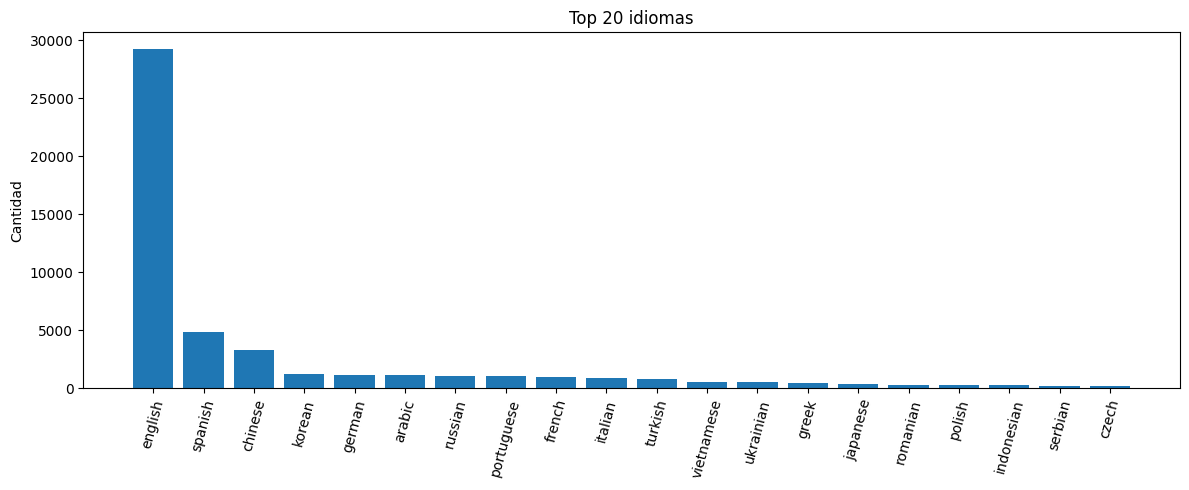

In [34]:

# ============================================================
# 8) DISTRIBUCIÓN DE IDIOMAS
# ============================================================
lang_counts = (
    eda["language_norm"]
    .value_counts(dropna=False)
    .rename_axis("language")
    .reset_index(name="count")
)
lang_counts["pct"] = (lang_counts["count"] / len(eda) * 100).round(2)

display(lang_counts.head(25))

plt.figure(figsize=(12, 5))
plt.bar(lang_counts["language"].head(20), lang_counts["count"].head(20))
plt.xticks(rotation=75)
plt.title("Top 20 idiomas")
plt.ylabel("Cantidad")
plt.tight_layout()
plt.show()


In [35]:

# ============================================================
# 9) CALIDAD POR IDIOMA
# ============================================================
lang_quality = (
    eda.groupby("language_norm")
    .agg(
        rows=("language_norm", "size"),
        pct_total=("language_norm", lambda s: round(len(s) / len(eda) * 100, 2)),
        extract_ok_rate=("extract_ok", lambda s: round(float(pd.Series(s).mean() * 100), 2)),
        fetched_ok_rate=("fetched_ok", lambda s: round(float(pd.Series(s).mean() * 100), 2)),
        mean_headline_len=("headline_len", "mean"),
        mean_snippet_len=("snippet_len", "mean"),
        mean_body_len=("body_len", "mean"),
        mean_full_text_len=("full_text_len", "mean"),
        texto_util_rate=("has_text", lambda s: round(float(pd.Series(s).mean() * 100), 2)),
    )
    .sort_values("rows", ascending=False)
)
display(lang_quality.head(25))


,rows,pct_total,extract_ok_rate,fetched_ok_rate,mean_headline_len,mean_snippet_len,mean_body_len,mean_full_text_len,texto_util_rate
language_norm,,,,,,,,,
english,29214,57.71,76.00,77.11,70.541590,106.448039,3513.677791,3692.198124,96.54
spanish,4868,9.62,90.55,91.41,82.102095,155.971857,6026.407354,6266.296015,99.26
chinese,3282,6.48,80.01,88.45,35.294028,63.342474,1868.474101,1968.818099,86.81
korean,1252,2.47,93.85,99.76,38.238818,178.738019,1728.016773,1946.894569,95.53
german,1167,2.31,70.69,71.29,64.965724,116.193659,5316.251071,5498.832905,94.69
arabic,1139,2.25,57.07,58.30,59.888499,81.769096,1872.356453,2015.162423,86.83
russian,1054,2.08,81.12,81.50,71.794118,114.420304,2963.392789,3151.231499,97.25
portuguese,1039,2.05,81.23,82.96,79.709336,116.429259,3713.820019,3911.585178,98.56
french,936,1.85,79.38,80.13,80.063034,147.259615,3402.054487,3630.975427,97.44


,source,count,pct
0,yahoo.com,669,1.32
1,163.com,483,0.95
2,finance.sina.com.cn,476,0.94
3,biz.heraldcorp.com,256,0.51
4,insidermonkey.com,241,0.48
5,news.mt.co.kr,237,0.47
6,collider.com,233,0.46
7,larepublica.pe,201,0.40
8,biztoc.com,191,0.38
9,finance.eastmoney.com,153,0.30


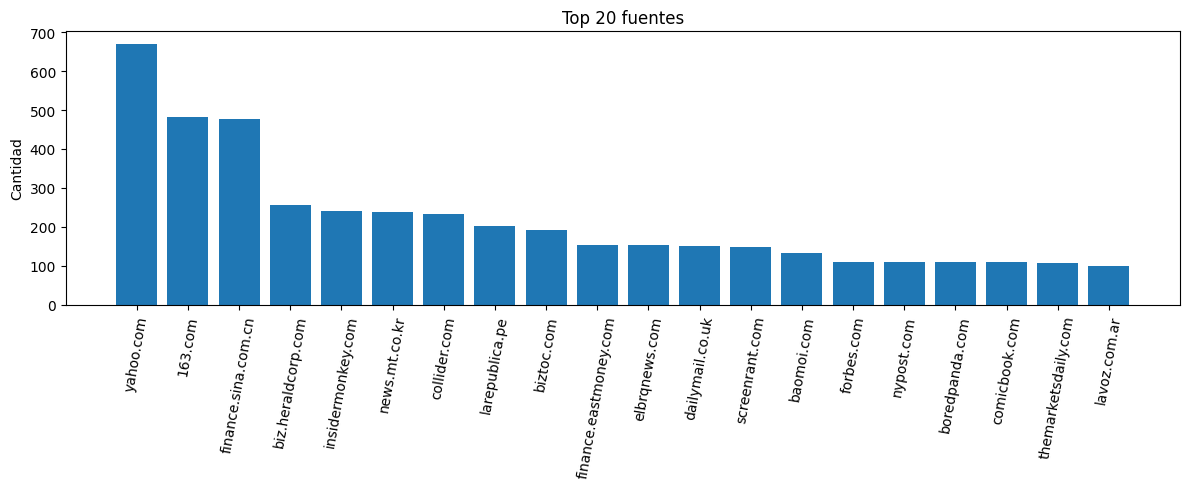

,domain,count,pct
0,yahoo.com,669,1.32
1,163.com,483,0.95
2,finance.sina.com.cn,476,0.94
3,biz.heraldcorp.com,256,0.51
4,insidermonkey.com,241,0.48
5,news.mt.co.kr,237,0.47
6,collider.com,233,0.46
7,larepublica.pe,201,0.40
8,biztoc.com,191,0.38
9,finance.eastmoney.com,153,0.30


In [36]:

# ============================================================
# 10) DISTRIBUCIÓN DE FUENTES Y DOMINIOS
# ============================================================
source_counts = (
    eda["source_norm"]
    .value_counts(dropna=False)
    .rename_axis("source")
    .reset_index(name="count")
)
source_counts["pct"] = (source_counts["count"] / len(eda) * 100).round(2)
display(source_counts.head(30))

plt.figure(figsize=(12, 5))
plt.bar(source_counts["source"].head(20), source_counts["count"].head(20))
plt.xticks(rotation=80)
plt.title("Top 20 fuentes")
plt.ylabel("Cantidad")
plt.tight_layout()
plt.show()

domain_counts = (
    eda["domain_norm"]
    .value_counts(dropna=False)
    .rename_axis("domain")
    .reset_index(name="count")
)
domain_counts["pct"] = (domain_counts["count"] / len(eda) * 100).round(2)
display(domain_counts.head(30))


,topic,count,pct
0,macro_risk,20250,40.00
1,universe,16374,32.34
2,tech_ai,14000,27.65


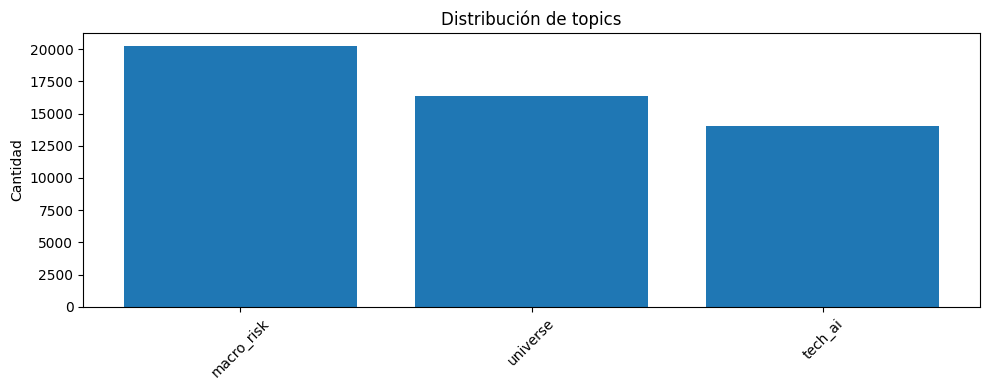

In [37]:

# ============================================================
# 11) TOPICS / PACKS
# ============================================================
topic_counts = (
    eda["topic_norm"]
    .value_counts(dropna=False)
    .rename_axis("topic")
    .reset_index(name="count")
)
topic_counts["pct"] = (topic_counts["count"] / len(eda) * 100).round(2)
display(topic_counts)

plt.figure(figsize=(10, 4))
plt.bar(topic_counts["topic"], topic_counts["count"])
plt.xticks(rotation=45)
plt.title("Distribución de topics")
plt.ylabel("Cantidad")
plt.tight_layout()
plt.show()


,count,mean,std,min,10%,25%,50%,75%,90%,95%,max
headline_len,50624.0,68.691609,26.486019,3.0,35.0,52.0,68.0,84.0,99.0,111.00,361.0
snippet_len,50624.0,115.638176,167.791922,0.0,0.0,1.0,111.0,158.0,222.0,299.00,9998.0
body_len,50624.0,3549.574885,8687.880434,0.0,0.0,556.0,2320.0,4375.0,6970.7,9524.00,459944.0
full_text_len,50624.0,3735.489096,8705.240736,4.0,68.0,759.0,2533.0,4605.0,7199.0,9749.25,460148.0


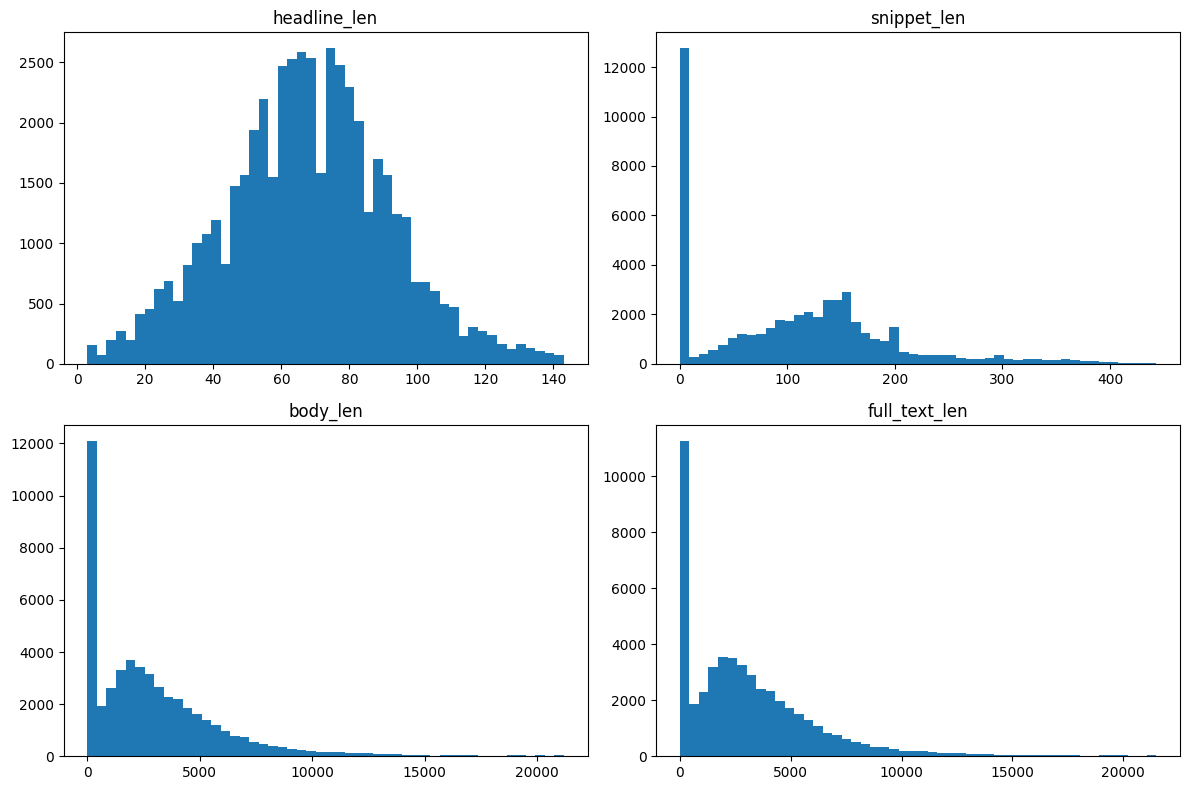

In [38]:

# ============================================================
# 12) LONGITUDES DE TEXTO
# ============================================================
length_stats = pd.DataFrame({
    "headline_len": describe_series_safe(eda["headline_len"]),
    "snippet_len": describe_series_safe(eda["snippet_len"]),
    "body_len": describe_series_safe(eda["body_len"]),
    "full_text_len": describe_series_safe(eda["full_text_len"]),
}).T
display(length_stats)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
cols = ["headline_len", "snippet_len", "body_len", "full_text_len"]
for ax, c in zip(axes.flatten(), cols):
    vals = pd.to_numeric(eda[c], errors="coerce").dropna()
    if len(vals):
        cap = vals.quantile(0.99)
        vals = vals[vals <= cap]
        ax.hist(vals, bins=50)
    ax.set_title(c)
plt.tight_layout()
plt.show()


,day,count
0,2025-01-01,307
1,2025-01-02,585
2,2025-01-03,235
3,2025-01-04,1046
4,2025-01-05,707


,day,count
85,2025-03-28,580
86,2025-03-29,575
87,2025-03-30,1134
88,2025-03-31,152
89,2025-04-01,331


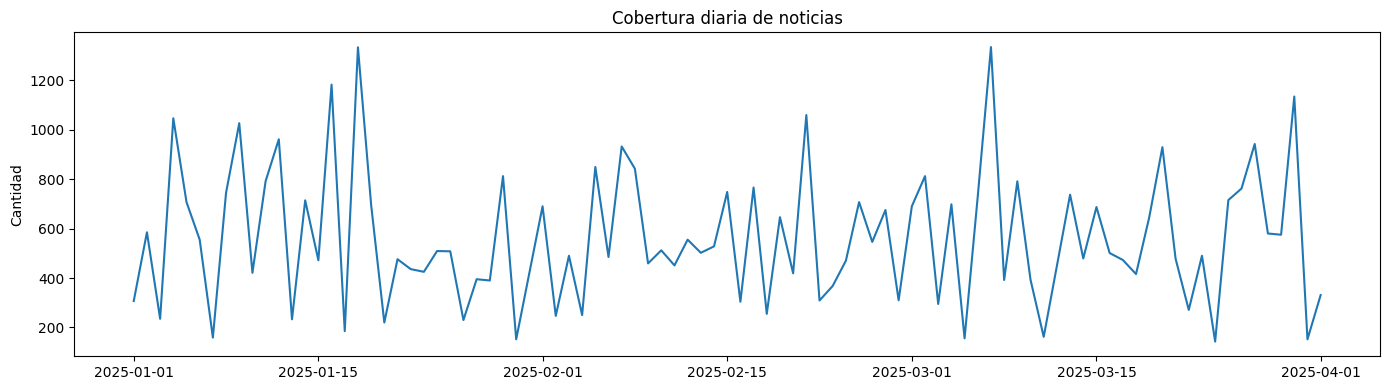

,week_end,count
0,2025-01-03,1127
1,2025-01-10,4659
2,2025-01-17,4539
3,2025-01-24,4095
4,2025-01-31,2487


,week_end,count
9,2025-03-07,4716
10,2025-03-14,3403
11,2025-03-21,4129
12,2025-03-28,3903
13,2025-04-04,2192


,weekly_count
count,14.000000
mean,3616.000000
std,1031.048906
min,1127.000000
10%,2280.500000
25%,3389.500000
50%,3923.000000
75%,4180.000000
90%,4623.000000
95%,4678.950000


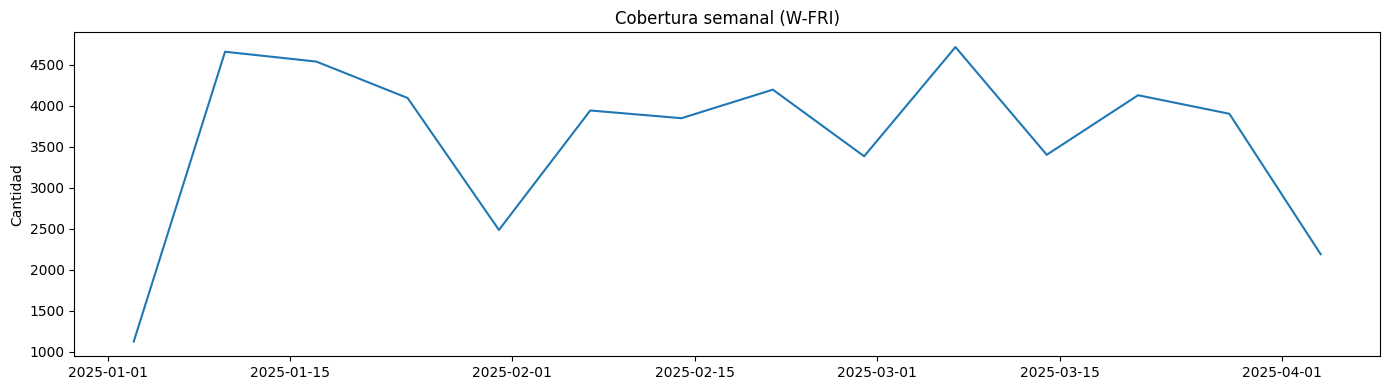

In [39]:

# ============================================================
# 13) COBERTURA TEMPORAL DIARIA Y SEMANAL
# ============================================================
daily_counts = (
    eda.dropna(subset=["timestamp_utc"])
       .assign(day=lambda x: x["timestamp_utc"].dt.tz_convert("UTC").dt.tz_localize(None).dt.normalize())
       .groupby("day")
       .size()
       .rename("count")
       .reset_index()
)
display(daily_counts.head())
display(daily_counts.tail())

plt.figure(figsize=(14, 4))
plt.plot(daily_counts["day"], daily_counts["count"])
plt.title("Cobertura diaria de noticias")
plt.ylabel("Cantidad")
plt.tight_layout()
plt.show()

weekly_counts = (
    eda.dropna(subset=["week_end"])
       .groupby("week_end")
       .size()
       .rename("count")
       .reset_index()
       .sort_values("week_end")
)
display(weekly_counts.head())
display(weekly_counts.tail())
display(describe_series_safe(weekly_counts["count"]).to_frame(name="weekly_count"))

plt.figure(figsize=(14, 4))
plt.plot(weekly_counts["week_end"], weekly_counts["count"])
plt.title("Cobertura semanal (W-FRI)")
plt.ylabel("Cantidad")
plt.tight_layout()
plt.show()


In [40]:

# ============================================================
# 14) DUPLICADOS RELEVANTES
# ============================================================
eda["headline_norm"] = eda["headline"].str.lower().str.replace(r"\s+", " ", regex=True).str.strip()
eda["snippet_norm"] = eda["snippet"].str.lower().str.replace(r"\s+", " ", regex=True).str.strip()

dup_url = int(eda["url"].duplicated(keep=False).sum()) if "url" in eda.columns else 0
dup_news_id = int(eda["news_id"].duplicated(keep=False).sum()) if "news_id" in eda.columns else 0
dup_headline = int(eda["headline_norm"].duplicated(keep=False).sum())

dup_summary = pd.DataFrame({
    "metric": ["dup_url_rows", "dup_news_id_rows", "dup_headline_rows"],
    "value": [dup_url, dup_news_id, dup_headline]
})
display(dup_summary)

if "url" in eda.columns and dup_url > 0:
    display(
        eda.loc[eda["url"].duplicated(keep=False), ["timestamp_utc", "source", "url", "headline"]]
        .sort_values("url")
        .head(20)
    )


,metric,value
0,dup_url_rows,0
1,dup_news_id_rows,0
2,dup_headline_rows,9937


In [41]:

# ============================================================
# 15) ÉXITO DE DESCARGA / EXTRACCIÓN
# ============================================================
quality = {
    "fetched_ok_rate_pct": round(float(eda["fetched_ok"].mean() * 100), 2),
    "extract_ok_rate_pct": round(float(eda["extract_ok"].mean() * 100), 2),
    "has_text_rate_pct": round(float(eda["has_text"].mean() * 100), 2),
}
display(pd.Series(quality, name="value").to_frame())

extract_by_source = (
    eda.groupby("source_norm")
       .agg(
           rows=("source_norm", "size"),
           extract_ok_rate=("extract_ok", lambda s: round(float(pd.Series(s).mean() * 100), 2)),
           fetched_ok_rate=("fetched_ok", lambda s: round(float(pd.Series(s).mean() * 100), 2)),
           mean_body_len=("body_len", "mean"),
       )
       .sort_values(["rows", "extract_ok_rate"], ascending=[False, False])
)
display(extract_by_source.head(30))


,value
fetched_ok_rate_pct,80.38
extract_ok_rate_pct,78.39
has_text_rate_pct,95.83


,rows,extract_ok_rate,fetched_ok_rate,mean_body_len
source_norm,,,,
yahoo.com,669,72.80,72.80,3512.801196
163.com,483,98.34,98.34,2252.142857
finance.sina.com.cn,476,99.79,100.00,3363.775210
biz.heraldcorp.com,256,100.00,100.00,1801.214844
insidermonkey.com,241,100.00,100.00,5835.709544
news.mt.co.kr,237,100.00,100.00,1831.362869
collider.com,233,100.00,100.00,7912.832618
larepublica.pe,201,98.51,98.51,3829.253731
biztoc.com,191,8.90,8.90,4154.586387


,ticker,count
0,META,1708
1,AMD,416
2,NVDA,142
3,TSM,91
4,AMZN,81
5,MSFT,80
6,ASML,79
7,AAPL,76
8,GOOGL,71
9,AVGO,43


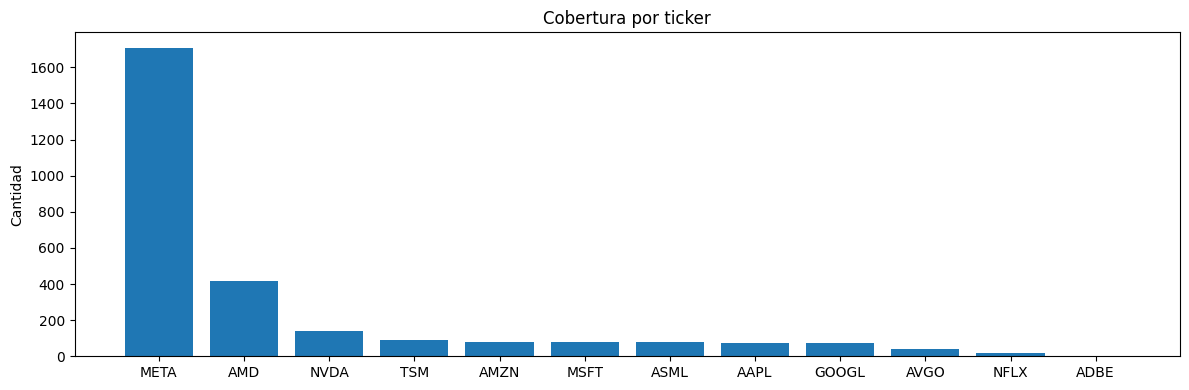

In [42]:

# ============================================================
# 16) COBERTURA DE TICKERS
# ============================================================
ticker_df = eda[["news_id", "language_norm", "ticker_tags_list"]].copy()
ticker_df["ticker_tags_list"] = ticker_df["ticker_tags_list"].map(lambda x: x if isinstance(x, list) else [])
ticker_expanded = ticker_df.explode("ticker_tags_list").rename(columns={"ticker_tags_list": "ticker"})
ticker_expanded = ticker_expanded[ticker_expanded["ticker"].notna() & (ticker_expanded["ticker"] != "")]

if len(ticker_expanded) == 0:
    print("No hay tickers detectados en ticker_tags_list.")
else:
    ticker_counts = (
        ticker_expanded["ticker"]
        .value_counts()
        .rename_axis("ticker")
        .reset_index(name="count")
    )
    display(ticker_counts.head(30))

    plt.figure(figsize=(12, 4))
    plt.bar(ticker_counts["ticker"].head(20), ticker_counts["count"].head(20))
    plt.title("Cobertura por ticker")
    plt.ylabel("Cantidad")
    plt.tight_layout()
    plt.show()


In [43]:

# ============================================================
# 17) TICKERS POR IDIOMA
# ============================================================
if "ticker_expanded" in globals() and len(ticker_expanded) > 0:
    ticker_lang = (
        ticker_expanded
        .groupby(["language_norm", "ticker"])
        .size()
        .rename("count")
        .reset_index()
        .sort_values(["language_norm", "count"], ascending=[True, False])
    )
    display(ticker_lang.head(40))
else:
    print("No hay tickers expandidos para cruzar con idioma.")


,language_norm,ticker,count
0,albanian,META,3
1,arabic,META,2
2,bosnian,META,5
3,bulgarian,META,2
4,catalan,META,4
11,chinese,META,171
6,chinese,AMD,80
5,chinese,AAPL,36
10,chinese,GOOGL,32
12,chinese,MSFT,31


In [44]:

# ============================================================
# 18) EJEMPLOS POR IDIOMA
# ============================================================
for lang in lang_counts["language"].head(5).tolist():
    print("=" * 100)
    print("IDIOMA:", lang)
    subset = eda.loc[
        eda["language_norm"] == lang,
        ["timestamp_utc", "source", "headline", "snippet", "body_len", "topic_norm"]
    ].head(5)
    display(subset)


IDIOMA: english


,timestamp_utc,source,headline,snippet,body_len,topic_norm
0,2025-02-25 23:30:00+00:00,businessinsider.com,Readers told us that maybe DOGE's email request is a good idea,"Readers shared their takes on DOGE's controversial request for accomplishment lists — many saw potential benefits, despite concerns abou...",5437,universe
2,2025-01-28 00:15:00+00:00,palestinechronicle.com,"Sheikh Qassem : No Deadline Extensions , Resistance Will Decide the Response",,0,tech_ai
4,2025-03-01 00:15:00+00:00,houston.culturemap.com,New podcast celebrates legacy of Houston politician Sen. Lloyd Bentsen,Sen. Lloyd Bentsen was a towering figure in the Democratic Party and a Houston icon. His family is now producing a six-part podcast cele...,2197,macro_risk
5,2025-02-28 23:45:00+00:00,kffm.com,Microsoft to Hang Up Skype in May After 14 Years of Service,The video communication platform became so popular it was often used as the de-facto term for digital in person communication.,1986,universe
6,2025-02-09 00:00:00+00:00,freerepublic.com,8.0-magnitude earthquake hits the Caribbean Sea,,3163,macro_risk


IDIOMA: spanish


,timestamp_utc,source,headline,snippet,body_len,topic_norm
16,2025-03-03 23:45:00+00:00,diariovasco.com,Una promotora triplicará el número de pisos de un edificio del Ensanche de Donostia tras su reconstrucción | El Diario Vasco,"Naiz Homes comercializa 27 nuevas viviendas con precios entre 500.000 y 2 millones de euros en la calle Alfonso VIII, junto a la plaza d...",4591,universe
27,2025-01-16 23:15:00+00:00,3djuegos.com,"""Estamos completamente comprometidos"". Microsoft y Activision niegan los últimos rumores que se han difundido sobre Xbox",Ha pasado más de un año desde que Activision Blizzard se unió a Xbox después de una adquisición que fue muy discutida en los organismos ...,2143,tech_ai
42,2025-03-26 00:00:00+00:00,diariodelsur.com.co,"Colombia enfrenta un desajuste de talento del 66%, por debajo del promedio mundial - Diario del Sur",El talento colombiano esta por debajo del promedio mundial,6480,tech_ai
47,2025-01-10 22:30:00+00:00,tiempodesanjuan.com,"Las fotos de confirmación de la China y Mauro Icardi, ¿IA o realidad?: la opinión de un especialista sanjuanino","La ""China"" Suárez y Mauro Icardi confirmaron su relación este jueves mediante un posteo con varias fotos. A varios usuarios les pareció ...",1129,tech_ai
48,2025-01-04 20:15:00+00:00,eleconomista.com.mx,"Inteligencia artificial y salud mental: beneficios, desafíos y riesgos",Hace un tiempo escribí sobre los beneficios y desafíos de la inteligencia artificial (IA) en salud y este 2025 se anticipa que esta tecn...,5593,tech_ai


IDIOMA: chinese


,timestamp_utc,source,headline,snippet,body_len,topic_norm
3,2025-02-11 00:15:00+00:00,news.cn,数字经济高效赋能千行百业,,2096,tech_ai
14,2025-02-20 00:00:00+00:00,storm.mg,觀點投書：美國挺台有變，台獨還在作夢 | 王景嚴 | 評論,美國國務院官網2月13日更新美台關係現況頁面，刪除「不支持台獨」立場文字。新增「希望兩岸分歧以和平、非脅迫、兩岸人民都能接受的方式解決」。,1099,macro_risk
19,2025-03-23 23:45:00+00:00,news.ycwb.com,ç¬¬44å±å¹¿ä¸çâç±é¸å¨âå¼å¹ ç±é¸æ¤é¸å ±ç»ç¾å¥½ç»å·,é¿éå±åºä¼å¤ä»æ¥æ°åºççé¸ç±»å¹¼å´½ãç¾½ç¿¼æªä¸°çå¹¼é¸ä»¬åæ¸¸å®¢ä»¬å±ç°äºæ¥å¤©ççå½åã,2140,tech_ai
33,2025-02-05 00:15:00+00:00,ww2.money-link.com.tw,證期權,MONEY-LINK 富聯網首創「看懂財經、解讀資訊」，幫助投資人看懂、讀懂、聽懂全球股市/債市/匯市財經訊息，係台灣最大財經軟體資訊商精誠資訊旗下唯一開放式資訊平台。,632,universe
55,2025-02-19 23:30:00+00:00,news.china.com.cn,探访上海首座人形机器人量产工厂 年产望达数千台,中国网--网上中国,1294,tech_ai


IDIOMA: korean


,timestamp_utc,source,headline,snippet,body_len,topic_norm
1,2025-01-24 23:15:00+00:00,edaily.co.kr,글로벌 생명과학 M&A 올해 트렌드는?[제약·바이오 해외토픽],올해 글로벌 생명과학(헬스케어) 인수합병(M&A) 트렌드는 인공지능(AI)과 중국이 될 것이란 전망이 제기됐다. 인공지능. (사진=연합뉴스)25일 한국바이오협회 바이오경제연구센터에 따르면 글로벌 생명과학분야에 있어 지난해는 리셋의 해로 평가된다...,1037,tech_ai
17,2025-03-29 23:45:00+00:00,fnnews.com,"트럼프, 내달 2일 상호관세 예고…글로벌 무역전쟁 전면전 확산","트럼프, 내달 2일 상호관세 예고…글로벌 무역전쟁 전면전 확산 ""美, 수십년간 탈취 당해""…각국에 '先부과 後협상' 수순 밟을듯 각국, 자국 관세율에 촉각…통상 대혼란·무역 질서 붕괴 가능성 '對美 흑자' 韓 타격 클듯…車·반도체 등 품목관세 ...",3414,tech_ai
20,2025-03-25 00:15:00+00:00,koreatimes.com,"뉴욕증시, ‘유연한 상호관세’ 기대감 고조…동반 강세 마감 - 미주 한국일보",뉴욕증시의 3대 주가지수가 동반 강세를 보였다.4월 2일 발효되는 상호 관세에서 많은 국가가 감면 혜택을 볼 수 있으며 관세 부과 품목도 축소될 수 있다는 소식에 낙관론이 퍼지며 주가를 강하게 밀어 올렸다.24일(미국 동부시간) 뉴욕증권거래소(...,2782,macro_risk
69,2025-02-14 23:30:00+00:00,biz.heraldcorp.com,“넷플릭스 손잡더니” 2월에만 주가 16% 급등···업계 ‘탑픽’ 등극한 이 종목 [투자360],"SBS 주가, 2월 들어 16.22% 상승 넷플릭스 콘텐츠 계약·드라마 인기·호실적 뒷받침 지난 4일 실적 발표 후 주가 10% 급등 티빙과 손잡은 KBS···방송사·OTT 공급 계약",1919,universe
74,2025-03-26 00:00:00+00:00,newspim.com,[현장에서] 1·2세대 실손보험 강제전환?...혼란만 부추기는 보험 개혁,"[서울=뉴스핌] 이윤애 기자 = ""1·2세대 초기 실손보험은 자기부담금이 적고 보장이 넓어 손해율이 높다고 생각하지만, 전혀 그렇지 않습니다.""""강제 전환은 법 개정이 필요하며, 국회를 중심으로 한 논의와 사회적 합의가 선행돼야 합니다.""전현욱",1553,universe


IDIOMA: german


,timestamp_utc,source,headline,snippet,body_len,topic_norm
123,2025-02-06 00:15:00+00:00,n-tv.de,US-Börsen tasten sich voran,"Die Wall Street bleibt auf Erholungskurs - doch der ist fragil. Wie groß die Nervosität angesichts eines drohenden Handelskriegs ist, ze...",3977,macro_risk
130,2025-03-09 23:30:00+00:00,funkytaurusmedia.com,Datenschutz,,91254,universe
159,2025-01-04 23:45:00+00:00,sueddeutsche.de,"Selenskij: Selenskij bietet an, nordkoreanische Soldaten auszutauschen","Der ukrainische Präsident sagt, er erwarte die Gefangennahme weiterer Soldaten aus dem Partnerland Russlands.",27660,macro_risk
238,2025-02-07 00:15:00+00:00,aerzteblatt.de,Radiotherapie – Paradigmenwechsel zur echtzeitadaptiven Bestrahlung – Deutsches Ärzteblatt,,1144,tech_ai
252,2025-04-01 00:00:00+00:00,deutschlandfunk.de,Myanmar - Zahl der Toten nach Erdbeben steigt auf mehr als 2.000,Nach dem verheerenden Erdbeben in Myanmar ist die Zahl der bestätigten Todesopfer auf mehr als 2.000 gestiegen. Nach Angaben der Militär...,2022,macro_risk


In [45]:

# ============================================================
# 19) SEMANAS CON MÁS VOLUMEN
# ============================================================
top_weeks = weekly_counts.sort_values("count", ascending=False).head(10)
display(top_weeks)

for wk in top_weeks["week_end"].head(3):
    print("=" * 100)
    print("SEMANA:", wk)
    subset = eda.loc[
        eda["week_end"] == wk,
        ["timestamp_utc", "language_norm", "source", "headline", "topic_norm", "ticker_tags_list"]
    ].head(20)
    display(subset)


,week_end,count
9,2025-03-07,4716
1,2025-01-10,4659
2,2025-01-17,4539
7,2025-02-21,4197
11,2025-03-21,4129
3,2025-01-24,4095
5,2025-02-07,3943
12,2025-03-28,3903
6,2025-02-14,3849
10,2025-03-14,3403


SEMANA: 2025-03-07 00:00:00


,timestamp_utc,language_norm,source,headline,topic_norm,ticker_tags_list
4,2025-03-01 00:15:00+00:00,english,houston.culturemap.com,New podcast celebrates legacy of Houston politician Sen. Lloyd Bentsen,macro_risk,[]
13,2025-03-02 23:15:00+00:00,english,amny.com,Andrew Cuomo Makes First Speech in Mayoral Race,universe,[]
16,2025-03-03 23:45:00+00:00,spanish,diariovasco.com,Una promotora triplicará el número de pisos de un edificio del Ensanche de Donostia tras su reconstrucción | El Diario Vasco,universe,[]
31,2025-03-02 00:15:00+00:00,english,thedigitalcourier.com,Ukraine Zelensky gets warm welcome from united kingdom Starmer,macro_risk,[]
45,2025-03-07 00:00:00+00:00,english,hypebeast.com,CLOT and adidas Present the Stan Smith Espadrille,tech_ai,[]
49,2025-03-07 20:15:00+00:00,english,bbc.com,"Doorman, 21, left infertile in revenge stabbing at Doncaster pub",universe,[]
63,2025-03-07 23:45:00+00:00,spanish,extra.ec,MasterChef Celebrity Ecuador: ¿Cómo el reality impulso la unión entre cantantes?,tech_ai,[]
64,2025-03-06 00:15:00+00:00,english,midnorthmonitor.com,Elon Musk dumps on 'SNL's' spoof of Trump-Zelenskyy clash and Mike Myers impression,macro_risk,[]
79,2025-03-04 22:15:00+00:00,english,modernreaders.com,Taiwan Semiconductor Manufacturing ( NYSE : TSM ) Shares Up 1 . 4 % – Still a Buy ?,tech_ai,[TSM]
91,2025-03-04 00:15:00+00:00,english,paherald.sk.ca,Premier Moe talks D.C. trip; says tariffs will hurt U.S. families,macro_risk,[]


SEMANA: 2025-01-10 00:00:00


,timestamp_utc,language_norm,source,headline,topic_norm,ticker_tags_list
28,2025-01-04 00:15:00+00:00,greek,inewsgr.com,Στα « Νέα Σαββατοκύριακο »: Αυταρχισμός λαϊκισμός ανασφάλεια,macro_risk,[]
29,2025-01-08 00:15:00+00:00,english,hillingdontimes.co.uk,"Man who exploded Tesla truck outside Trump hotel used generative AI , police say",macro_risk,[]
47,2025-01-10 22:30:00+00:00,spanish,tiempodesanjuan.com,"Las fotos de confirmación de la China y Mauro Icardi, ¿IA o realidad?: la opinión de un especialista sanjuanino",tech_ai,[]
48,2025-01-04 20:15:00+00:00,spanish,eleconomista.com.mx,"Inteligencia artificial y salud mental: beneficios, desafíos y riesgos",tech_ai,[]
50,2025-01-08 00:15:00+00:00,english,africa-confidential.com,Fears for Goma grow as M23 continues gains in North Kivu,macro_risk,[]
51,2025-01-05 22:30:00+00:00,spanish,clarin.com,Conflicto en puerta: el Gobierno también apuesta a paritarias por debajo de la inflación con los gremios estatales,macro_risk,[]
56,2025-01-08 23:30:00+00:00,spanish,surysur.net,"Savio: Chile, un país de gran individualismo, con sentido de comunidad reducido - SurySur",tech_ai,[META]
78,2025-01-09 00:15:00+00:00,spanish,nortedigital.mx,Ciudadanos piden al Ayuntamiento reflexionar sobre inseguridad vial si autorizan licencias permanentes - Norte de Ciudad Juárez,macro_risk,[]
90,2025-01-08 00:15:00+00:00,english,radio.foxnews.com,Brooke Singman Stops By To Discuss Meta's Censorship Reversal,universe,[META]
106,2025-01-09 21:15:00+00:00,albanian,syri.net,Postimi - E vërteta rreth zjarrit në shenjën ikonë të Hollivudit në Los Anxhelos,tech_ai,[]


SEMANA: 2025-01-17 00:00:00


,timestamp_utc,language_norm,source,headline,topic_norm,ticker_tags_list
10,2025-01-16 23:45:00+00:00,english,mediaite.com,Economist Editor in Chief Warns the ‘Trump Doctrine’ Could Result in ‘Chaos on a Global Scale’,macro_risk,[]
23,2025-01-14 00:00:00+00:00,english,editorial.rottentomatoes.com,Weekend Box Office: Den of Thieves 2: Pantera Scores a Win for Lionsgate,universe,[]
27,2025-01-16 23:15:00+00:00,spanish,3djuegos.com,"""Estamos completamente comprometidos"". Microsoft y Activision niegan los últimos rumores que se han difundido sobre Xbox",tech_ai,[]
30,2025-01-14 22:30:00+00:00,french,lavoixdusud.com,L'élection canadienne serait dans la mire d'Elon Musk - La Voix du Sud,tech_ai,[]
39,2025-01-11 22:00:00+00:00,english,nsnews.com,Cybersecurity breach of Nova Scotia school system could have financial impact,tech_ai,[]
40,2025-01-11 23:30:00+00:00,english,makeuseof.com,"Why I Prefer ""Good Enough"" Headphones Over Top-of-the-Line Models",universe,[]
46,2025-01-12 23:00:00+00:00,arabic,26sep.net,محافظ البيضاء في حوار لـ« 26 سبتمبر »: أبناء البيضاء يدركون حجم المؤامرات التي يحيكها الأعداء,macro_risk,[]
72,2025-01-14 22:45:00+00:00,english,metrodailyng.com,Tinubu appoints Folashade Adekaiyaoja as first DSS Deputy DG - METRO DAILY Ng,tech_ai,[]
73,2025-01-13 23:30:00+00:00,chinese,society.people.com.cn,快看 ， 我们的 空中校车 （ 暖相册 ） -- 社会 · 法治 -- 人民网,tech_ai,[]
82,2025-01-14 00:00:00+00:00,english,examiner.com.au,More insurance pain possible following LA fires,macro_risk,[]


In [46]:

# ============================================================
# 20) FILTRADO SOLO INGLÉS
# ============================================================
eda_en = eda.loc[eda["language_norm"] == "english"].copy()

print("Rows total      :", len(eda))
print("Rows only EN    :", len(eda_en))
print("Pct only EN     :", round(len(eda_en) / len(eda) * 100, 2) if len(eda) else 0)

en_summary = {
    "rows_en": int(len(eda_en)),
    "extract_ok_rate_en_pct": round(float(eda_en["extract_ok"].mean() * 100), 2) if len(eda_en) else None,
    "has_text_rate_en_pct": round(float(eda_en["has_text"].mean() * 100), 2) if len(eda_en) else None,
    "sources_en": int(eda_en["source_norm"].nunique()) if len(eda_en) else 0,
    "domains_en": int(eda_en["domain_norm"].nunique()) if len(eda_en) else 0,
    "weeks_en": int(eda_en["week_end"].nunique()) if len(eda_en) else 0,
    "fecha_min_en": str(eda_en["timestamp_utc"].min()) if len(eda_en) else None,
    "fecha_max_en": str(eda_en["timestamp_utc"].max()) if len(eda_en) else None,
}
display(pd.Series(en_summary, name="value").to_frame())


Rows total      : 50624
Rows only EN    : 29214
Pct only EN     : 57.71


,value
rows_en,29214
extract_ok_rate_en_pct,76.0
has_text_rate_en_pct,96.54
sources_en,4704
domains_en,4704
weeks_en,14
fecha_min_en,2025-01-01 20:30:00+00:00
fecha_max_en,2025-04-01 00:15:00+00:00


,weekly_count_en
count,14.000000
mean,2086.714286
std,648.710132
min,560.000000
10%,1270.900000
25%,1858.500000
50%,2286.000000
75%,2444.750000
90%,2744.000000
95%,2820.800000


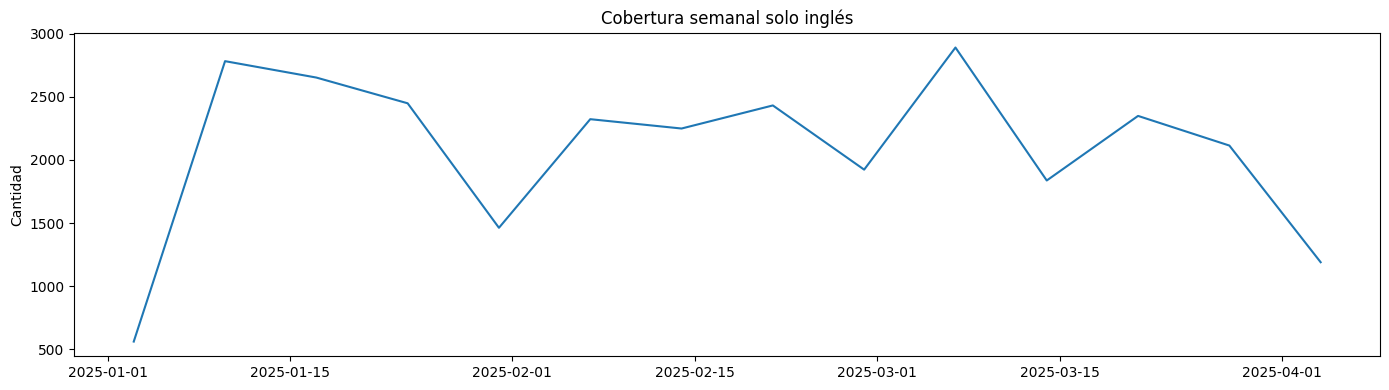

In [47]:

# ============================================================
# 21) COBERTURA SEMANAL SOLO INGLÉS
# ============================================================
weekly_counts_en = (
    eda_en.dropna(subset=["week_end"])
          .groupby("week_end")
          .size()
          .rename("count")
          .reset_index()
          .sort_values("week_end")
)

if len(weekly_counts_en):
    display(describe_series_safe(weekly_counts_en["count"]).to_frame(name="weekly_count_en"))

    plt.figure(figsize=(14, 4))
    plt.plot(weekly_counts_en["week_end"], weekly_counts_en["count"])
    plt.title("Cobertura semanal solo inglés")
    plt.ylabel("Cantidad")
    plt.tight_layout()
    plt.show()
else:
    print("No hay cobertura semanal en inglés.")


In [48]:

# ============================================================
# 22) RECOMENDACIÓN AUTOMÁTICA
# ============================================================
recommendation = {
    "usar_solo_ingles_v1": bool(len(eda_en) >= 10000),
    "razon": (
        "Hay suficiente volumen en inglés para una V1 estable."
        if len(eda_en) >= 10000
        else "El volumen en inglés parece bajo; conviene revisar si se amplía el rango o si se adopta enfoque multilingüe."
    ),
    "suficiencia_cobertura_semanal_en": bool(
        len(weekly_counts_en) > 30 and weekly_counts_en["count"].median() >= 10
    ) if len(weekly_counts_en) else False
}
display(pd.Series(recommendation, name="value").to_frame())


,value
usar_solo_ingles_v1,True
razon,Hay suficiente volumen en inglés para una V1 estable.
suficiencia_cobertura_semanal_en,False


In [49]:

# ============================================================
# 23) GUARDAR VERSIÓN SOLO INGLÉS
# ============================================================
SAVE_ENGLISH = True

if SAVE_ENGLISH:
    out_parquet = BASE_DIR / "news_data" / "raw" / "news_raw_gdelt_en.parquet"
    out_csv = BASE_DIR / "news_data" / "raw" / "news_raw_gdelt_en.csv"

    cols_to_save = [c for c in df.columns if c in eda_en.columns]
    extra_cols = [c for c in ["timestamp_utc", "language_norm", "headline_len", "snippet_len", "body_len", "full_text_len", "week_end"] if c in eda_en.columns]
    save_cols = cols_to_save + [c for c in extra_cols if c not in cols_to_save]

    save_df = eda_en[save_cols].copy()

    parquet_saved = False
    parquet_error = None

    try:
        save_df.to_parquet(out_parquet, index=False)
        parquet_saved = True
    except Exception as e:
        parquet_error = f"{type(e).__name__}: {e}"

    save_df.to_csv(out_csv, index=False, encoding="utf-8-sig")

    print("Guardado CSV:")
    print(out_csv)

    if parquet_saved:
        print("Guardado Parquet:")
        print(out_parquet)
    else:
        print("Parquet no se pudo guardar en este entorno.")
        print("Motivo:", parquet_error)
        print("Si quieres habilitarlo, instala pyarrow o fastparquet.")


Guardado CSV:
D:\QuantMahoraga\final_model\news_mahoraga\news_data\raw\news_raw_gdelt_en.csv
Guardado Parquet:
D:\QuantMahoraga\final_model\news_mahoraga\news_data\raw\news_raw_gdelt_en.parquet


In [50]:

# ============================================================
# 24) CHECK FINAL PARA LA SIGUIENTE ETAPA
# ============================================================
checklist = pd.DataFrame({
    "check": [
        "Hay suficientes noticias totales",
        "Hay suficiente cobertura en inglés",
        "La extracción de texto es razonable",
        "La cobertura semanal parece usable",
        "Ya existe archivo solo inglés CSV para la V1",
        "Ya existe archivo solo inglés Parquet para la V1"
    ],
    "status": [
        bool(len(eda) >= 10000),
        bool(len(eda_en) >= 10000),
        bool((eda_en["extract_ok"].mean() >= 0.4) if len(eda_en) else False),
        bool((weekly_counts_en["count"].median() >= 10) if len(weekly_counts_en) else False),
        bool((BASE_DIR / "news_data" / "raw" / "news_raw_gdelt_en.csv").exists()) if SAVE_ENGLISH else False,
        bool((BASE_DIR / "news_data" / "raw" / "news_raw_gdelt_en.parquet").exists()) if SAVE_ENGLISH else False
    ]
})
display(checklist)


,check,status
0,Hay suficientes noticias totales,True
1,Hay suficiente cobertura en inglés,True
2,La extracción de texto es razonable,True
3,La cobertura semanal parece usable,True
4,Ya existe archivo solo inglés CSV para la V1,True
5,Ya existe archivo solo inglés Parquet para la V1,True
